In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")
project = rf.workspace("training-nnws5").project("pneumonia-jspg1")
version = project.version(1)
dataset = version.download("folder")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pneumonia-1 in folder:: 100%|██████████| 11666/11666 [00:01<00:00, 7953.81it/s]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,MaxPool2D, Flatten, Conv2D, GlobalAvgPool2D
from tensorflow.keras.callbacks import EarlyStopping

#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

bs = 64
base_dir = '/content/pneumonia-1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

#Callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

#Data Augmentation
train_datagen = ImageDataGenerator(
    rescale = 1./255.,
    rotation_range = 20,
    horizontal_flip = False,
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)

val_datagen = ImageDataGenerator(
    rescale = 1./255.
)

train_data = train_datagen.flow_from_directory(train_dir, batch_size = bs, target_size = (224,224), class_mode = 'categorical')
val_data = val_datagen.flow_from_directory(val_dir, batch_size = bs, target_size=(224,224), class_mode = 'categorical',shuffle = False)


Found 10497 images belonging to 2 classes.
Found 1161 images belonging to 2 classes.


In [ ]:
print('-'*100)
print('Dataset information')
print('-'*100)

print(f"Training Samples   : {train_data.samples}")
print(f"Validation Samples : {val_data.samples}")

print(f"Number of Classes  : {train_data.num_classes}")

print('Class mapping')
print(train_data.class_indices)

print(f'Image shape : {train_data.image_shape}')

----------------------------------------------------------------------------------------------------
Dataset information
----------------------------------------------------------------------------------------------------
Training Samples   : 10497
Validation Samples : 1161
Number of Classes  : 2
Class mapping
{'NORMAL': 0, 'PNEUMONIA': 1}
Image shape : (224, 224, 3)


In [ ]:
classes = train_data.classes
class_names = list(train_data.class_indices.keys())

counts = []

for i in range(len(class_names)):
    counts.append((classes == i).sum())

print('-'*100)
print("Class Distribution")
print('-'*100)

for name, count in zip(class_names, counts):
    print(f"{name}: {count}")

----------------------------------------------------------------------------------------------------
Class Distribution
----------------------------------------------------------------------------------------------------
NORMAL: 2841
PNEUMONIA: 7656


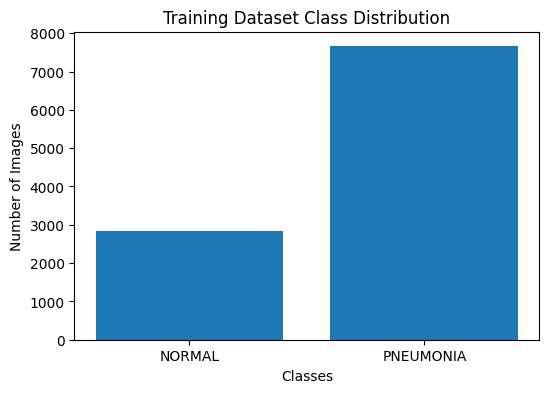

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(class_names, counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

----------------------------------------------------------------------------------------------------
Display Sample Images
----------------------------------------------------------------------------------------------------


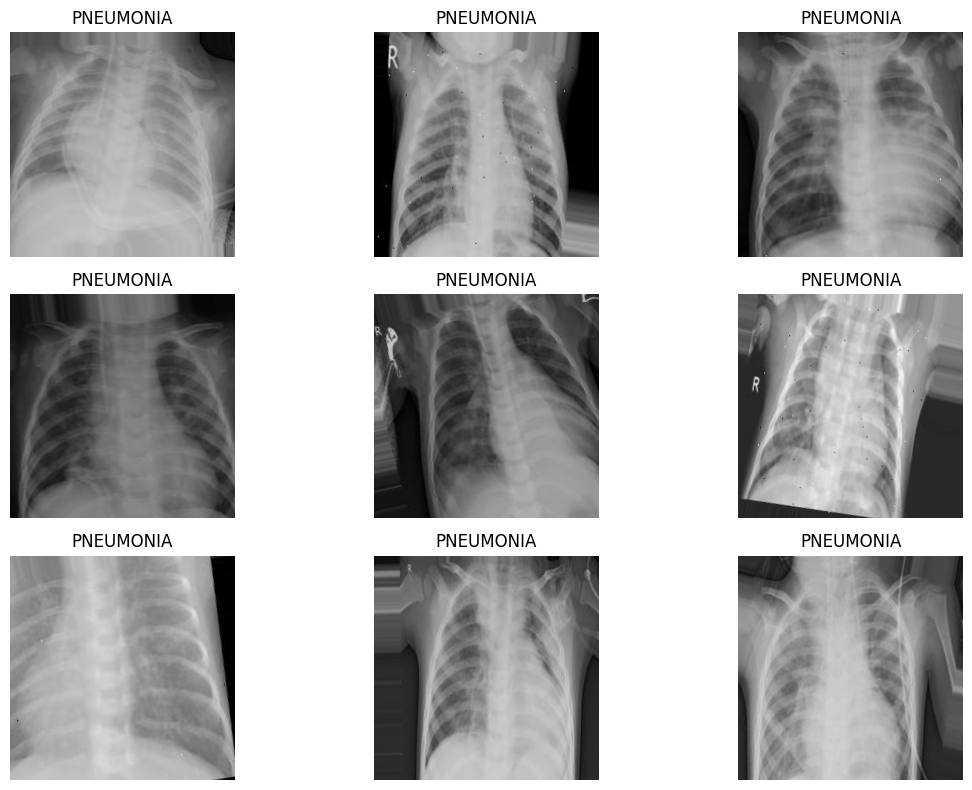

In [ ]:
print('-'*100)
print('Display Sample Images')
print('-'*100)

images, labels = next(train_data)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

# Baseline CNN

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu',padding = 'same',  input_shape = (224,224,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu',padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu',padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Conv2D(256, kernel_size = (3,3), activation = 'relu',padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size = (2,2)))

model.add((GlobalAvgPool2D()))
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation = 'softmax'))

print(model.summary())
model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'], optimizer = 'adam')
history = model.fit(train_data,  epochs = 30, validation_data = val_data, shuffle =True, callbacks = [early_stop])

val_error,val_accuracy = model.evaluate(val_data)

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 587,842 (2.24 MB)

 Trainable params: 586,882 (2.24 MB)

 Non-trainable params: 960 (3.75 KB)

None
{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}
2
2
Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 173s 955ms/step - accuracy: 0.8189 - loss: 0.3888 - val_accuracy: 0.7278 - val_loss: 5.8958
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 140s 846ms/step - accuracy: 0.8459 - loss: 0.3481 - val_accuracy: 0.7278 - val_loss: 3.8938
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 145s 880ms/step - accuracy: 0.8620 - loss: 0.3151 - val_accuracy: 0.7278 - val_loss: 2.5526
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 143s 867ms/step - accuracy: 0.8778 - loss: 0.2868 - val_accuracy: 0.7278 - val_loss: 0.6808
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 139s 842ms/step - accuracy: 0.8916 - loss: 0.2604 - val_accuracy: 0.7855 - val_loss: 0.5439
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 135s 820ms/step - accuracy: 0.9032 - loss: 0.2438 - val_accuracy: 0.8243 - val_loss: 0.3686
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 143s 864ms/step - accuracy: 0.9213 - loss: 0.2088 - val_accuracy: 0.6038 - val_loss: 0.9341
Epoch 8

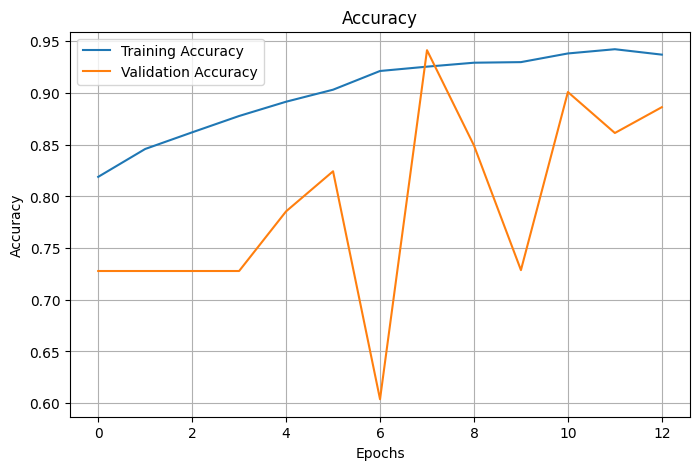

In [ ]:
fs = (15,5)

plt.figure(figsize = (fs))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[[261  55]
 [ 13 832]] 



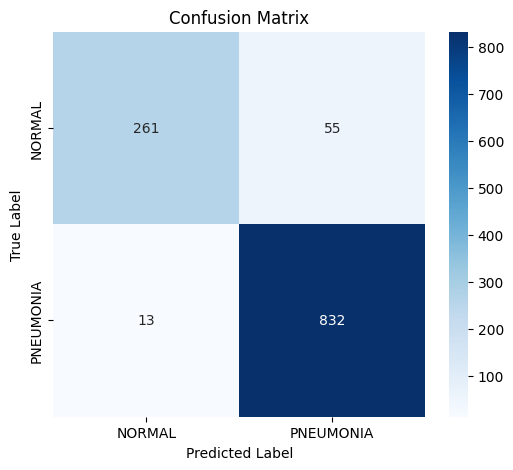

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred_prob = model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm,'\n')
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# VGG

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,MaxPool2D, Flatten, Conv2D, GlobalAvgPool2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import preprocess_input

#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

bs = 64
base_dir = '/content/pneumonia-1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

#Callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose=1
)

#Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 20,
    horizontal_flip = False,
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_data = train_datagen.flow_from_directory(train_dir, batch_size = bs, target_size = (224,224), class_mode = 'categorical')
val_data = val_datagen.flow_from_directory(val_dir, batch_size = bs, target_size=(224,224), class_mode = 'categorical',shuffle = False)


Found 10497 images belonging to 2 classes.
Found 1161 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top= False,input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = GlobalAvgPool2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

predictions = Dense(2, activation='softmax')(x)
model = Model(inputs = base_model.input, outputs =  predictions)
model.compile(loss = 'categorical_crossentropy' ,metrics = ['accuracy'], optimizer = 'adam')
model.summary()
print()

history = model.fit(train_data, validation_data = val_data, epochs = 30, callbacks=[early_stop],shuffle = True)
loss, accuracy = model.evaluate(val_data)
print(f'Loss : {loss}, Accuracy : {accuracy}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,02

 Total params: 14,980,418 (57.15 MB)

 Trainable params: 264,706 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8778 - loss: 0.3268 - val_accuracy: 0.8889 - val_loss: 0.3364
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 961ms/step - accuracy: 0.9238 - loss: 0.2011 - val_accuracy: 0.9423 - val_loss: 0.1708
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 965ms/step - accuracy: 0.9301 - loss: 0.1780 - val_accuracy: 0.9165 - val_loss: 0.2227
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 158s 957ms/step - accuracy: 0.9293 - loss: 0.1783 - val_accuracy: 0.9345 - val_loss: 0.1772
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 158s 956ms/step - accuracy: 0.9346 - loss: 0.1785 - val_accuracy: 0.8760 - val_loss: 0.3375
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 960ms/step - accuracy: 0.9356 - loss: 0.1663 - val_accuracy: 0.9500 - val_loss: 0.1230
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 160s 968ms/step - accuracy: 0.9351 - loss: 0.1692 - val_accuracy: 0.8854 - val_loss: 0.3362
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 959ms/step - accuracy: 0.9373 - l

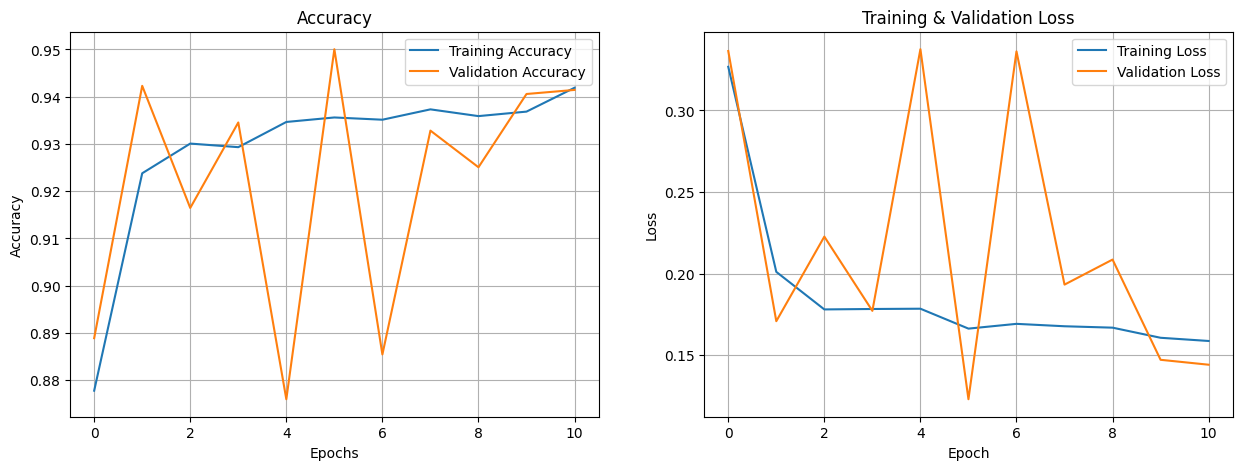

In [ ]:
fs = (15,5)

plt.figure(figsize = (fs))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[[297  19]
 [ 39 806]] 



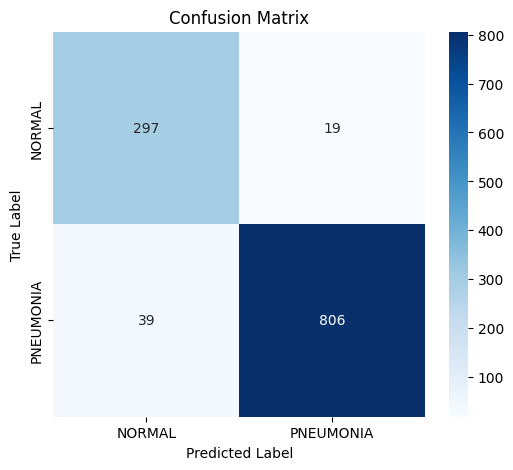

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred_prob = model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm,'\n')
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# GoogleNet (InceptionV3)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,MaxPool2D, Flatten, Conv2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.inception_v3 import InceptionV3,preprocess_input

#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

bs = 64
base_dir = '/content/pneumonia-1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

#Callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose=1
)

#Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 20,
    horizontal_flip = False,
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_data = train_datagen.flow_from_directory(train_dir, batch_size = bs, target_size = (299,299), class_mode = 'categorical')
val_data = val_datagen.flow_from_directory(val_dir, batch_size = bs, target_size=(299,299), class_mode = 'categorical',shuffle = False)


Found 10497 images belonging to 2 classes.
Found 1161 images belonging to 2 classes.


In [ ]:
base_model = InceptionV3(weights = 'imagenet', include_top = False, input_shape=(299,299,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x) # Explicitly add GlobalAveragePooling2D
x = Dense(512, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation = 'softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions) # Use base_model.input (singular)
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()
print()

history = model.fit(train_data, validation_data= val_data, epochs = 30, callbacks = [early_stop])

loss, accuracy = model.evaluate(val_data)
print(f'loss : {loss}   accuracy : {accuracy}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,854,946 (87.18 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 21,803,808 (83.17 MB)


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.8622 - loss: 0.3441 - val_accuracy: 0.7717 - val_loss: 0.5731
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.9131 - loss: 0.2199 - val_accuracy: 0.9371 - val_loss: 0.1753
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9215 - loss: 0.1998 - val_accuracy: 0.9121 - val_loss: 0.2421
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.9223 - loss: 0.1965 - val_accuracy: 0.9104 - val_loss: 0.2150
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.9226 - loss: 0.1869 - val_accuracy: 0.9397 - val_loss: 0.1619
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.9286 - loss: 0.1859 - val_accuracy: 0.8846 - val_loss: 0.2823
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9286 - loss: 0.1852 - val_accuracy: 0.9345 - val_loss: 0.1649
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9336 - loss: 0.1786 - val_acc

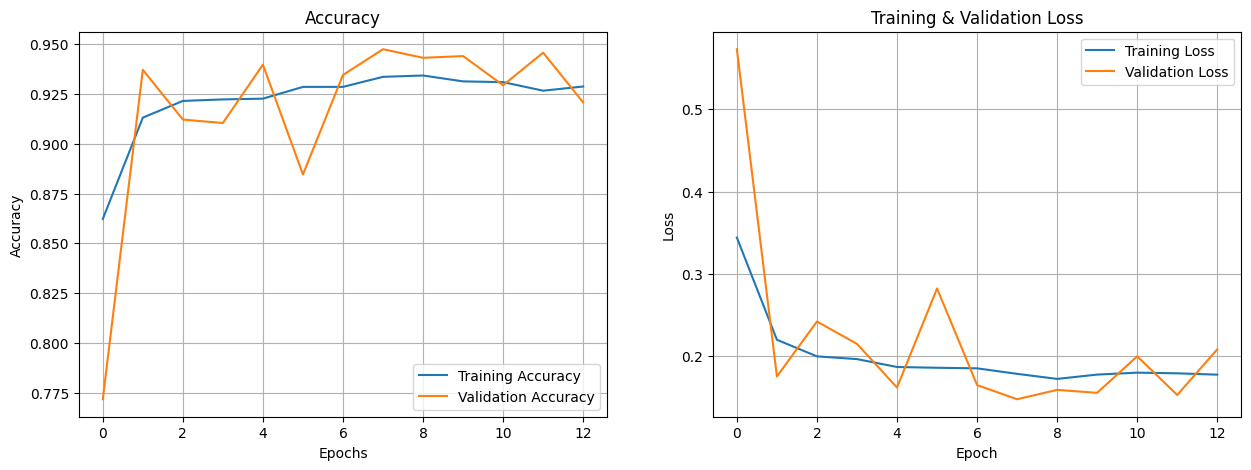

In [ ]:
fs = (15,5)

plt.figure(figsize = (fs))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[[296  20]
 [ 41 804]] 



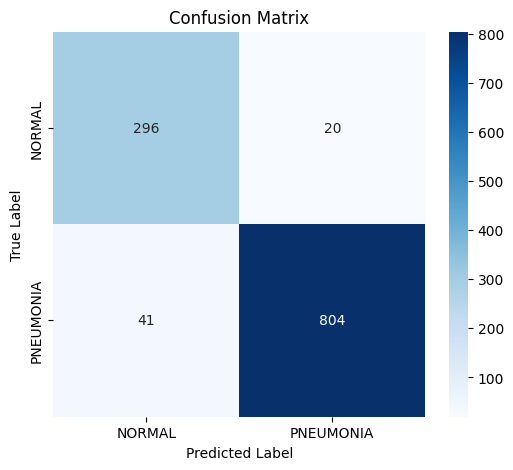

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred_prob = model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm,'\n')
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# ResNet50v2

In [ ]:
import os
import random
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

bs = 64
base_dir = '/content/pneumonia-1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

#Callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose=1
)

#Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 20,
    horizontal_flip = False,
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_data = train_datagen.flow_from_directory(train_dir, batch_size = bs, target_size = (224,224), class_mode = 'categorical')
val_data = val_datagen.flow_from_directory(val_dir, batch_size = bs, target_size=(224,224), class_mode = 'categorical',shuffle = False)


Found 10497 images belonging to 2 classes.
Found 1161 images belonging to 2 classes.


In [ ]:
base_model = ResNet50V2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512,  activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions)
model.compile(
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'],
    optimizer = 'adam'
)
print(model.summary())
history = model.fit(train_data, validation_data = val_data, epochs = 30,callbacks = [early_stop] )

loss, accuracy = model.evaluate(val_data)
print(f'Loss : {loss}   Accuracy :{accuracy}')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,616,962 (93.91 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 23,565,824 (89.90 MB)

None
Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8838 - loss: 0.3217 - val_accuracy: 0.9397 - val_loss: 0.1412
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 150s 907ms/step - accuracy: 0.9222 - loss: 0.2039 - val_accuracy: 0.9363 - val_loss: 0.1522
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 147s 889ms/step - accuracy: 0.9265 - loss: 0.1828 - val_accuracy: 0.9518 - val_loss: 0.1288
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 145s 881ms/step - accuracy: 0.9320 - loss: 0.1765 - val_accuracy: 0.9535 - val_loss: 0.1196
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 147s 889ms/step - accuracy: 0.9368 - loss: 0.1639 - val_accuracy: 0.9328 - val_loss: 0.1738
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 148s 894ms/step - accuracy: 0.9372 - loss: 0.1664 - val_accuracy: 0.9363 - val_loss: 0.1604
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 202s 897ms/step - accuracy: 0.9411 - loss: 0.1553 - val_accuracy: 0.9535 - val_loss: 0.1200
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 150s 908ms/step - accuracy: 0.9406

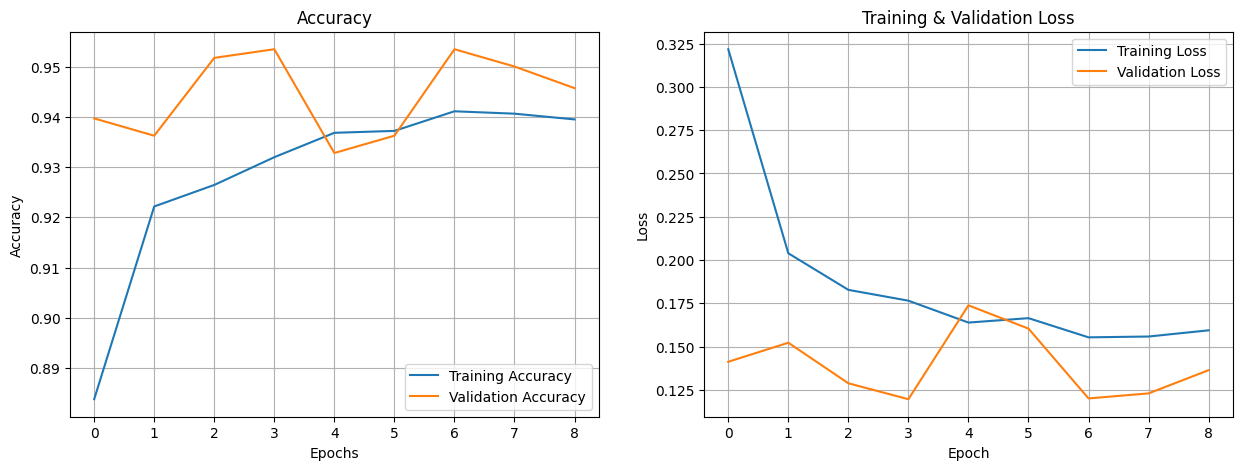

In [ ]:
import matplotlib.pyplot as plt

fs = (15,5)

plt.figure(figsize = (fs))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[[290  26]
 [ 28 817]] 



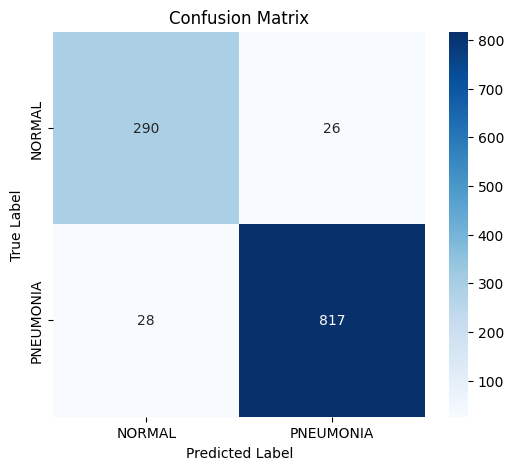

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred_prob = model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm,'\n')
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

Mounted at /content/drive
Saving ResNet50V2 experiment to:
/content/drive/MyDrive/Pneumonia_Project/ResNet50V2
Model saved.
Training history saved.


Model summary saved.
Configuration saved.
Class indices:
{'NORMAL': 0, 'PNEUMONIA': 1}


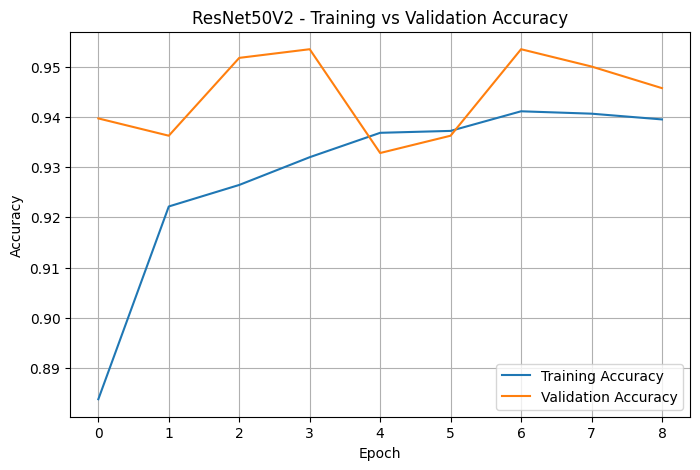

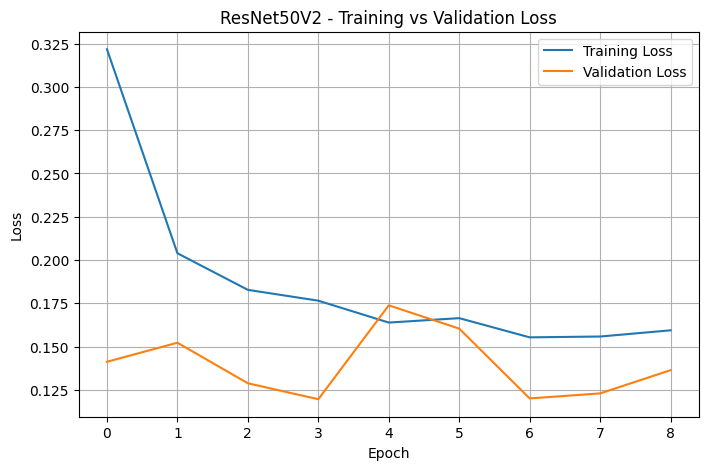

Found 1161 images belonging to 2 classes.

Validation class indices:
{'NORMAL': 0, 'PNEUMONIA': 1}

Validation samples:
1161
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9535 - loss: 0.1196

Model Evaluation
----------------
Validation Loss     : 0.1196
Validation Accuracy : 0.9535
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step


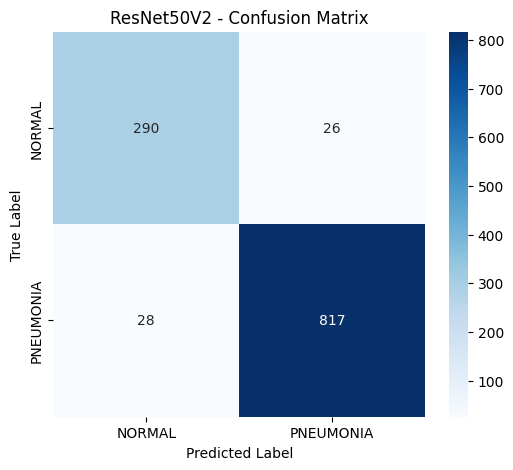


Classification Report
---------------------
              precision    recall  f1-score   support

      NORMAL     0.9119    0.9177    0.9148       316
   PNEUMONIA     0.9692    0.9669    0.9680       845

    accuracy                         0.9535      1161
   macro avg     0.9406    0.9423    0.9414      1161
weighted avg     0.9536    0.9535    0.9535      1161



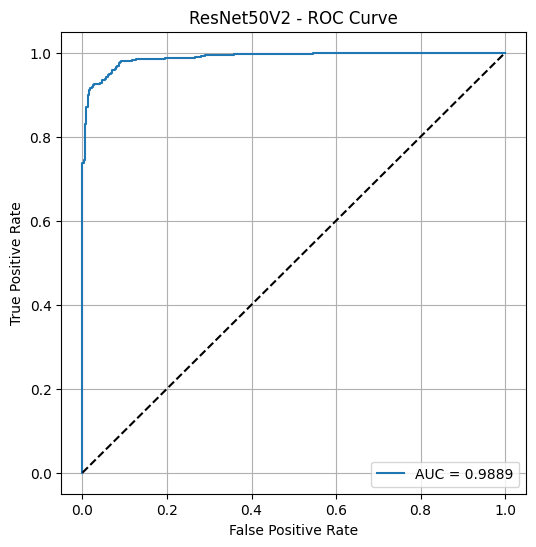


Final Metrics
-------------
        Model  Validation Loss  Accuracy  Precision    Recall  F1 Score  \
0  ResNet50V2          0.11959  0.953488   0.969158  0.966864  0.968009   

    ROC AUC  
0  0.988892  

RESNET50V2 EXPERIMENT SAVED SUCCESSFULLY

Location:
/content/drive/MyDrive/Pneumonia_Project/ResNet50V2

Saved files:
 - accuracy_curve.png
 - class_indices.json
 - classification_report.txt
 - config.json
 - confusion_matrix.png
 - evaluation.txt
 - history.pkl
 - loss_curve.png
 - metrics.csv
 - model_summary.txt
 - resnet50v2.keras
 - roc_curve.png


In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# ============================================================
# 1. MOUNT DRIVE & CREATE RESNET50V2 FOLDER
# ============================================================

drive.mount('/content/drive')

project_dir = "/content/drive/MyDrive/Pneumonia_Project"
resnet_dir = os.path.join(project_dir, "ResNet50V2")

os.makedirs(resnet_dir, exist_ok=True)

print("Saving ResNet50V2 experiment to:")
print(resnet_dir)


# ============================================================
# 2. SAVE TRAINED MODEL
# ============================================================

model.save(
    os.path.join(resnet_dir, "resnet50v2.keras")
)

print("Model saved.")


# ============================================================
# 3. SAVE TRAINING HISTORY
# ============================================================

with open(
    os.path.join(resnet_dir, "history.pkl"),
    "wb"
) as f:

    pickle.dump(history.history, f)

print("Training history saved.")


# ============================================================
# 4. SAVE MODEL SUMMARY
# ============================================================

with open(
    os.path.join(resnet_dir, "model_summary.txt"),
    "w"
) as f:

    model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

print("Model summary saved.")


# ============================================================
# 5. SAVE EXPERIMENT CONFIGURATION
# ============================================================

config = {

    "Model": "ResNet50V2",

    "Pretrained Weights": "ImageNet",

    "Base Model Frozen": True,

    "Input Size": "224x224x3",

    "Batch Size": bs,

    "Epochs Requested": 30,

    "Epochs Completed": len(
        history.history["loss"]
    ),

    "Optimizer": "Adam",

    "Learning Rate": 0.001,

    "Loss": "Categorical Crossentropy",

    "Output Activation": "Softmax",

    "Number of Classes": train_data.num_classes,

    "Classes": train_data.class_indices,

    "Preprocessing": "ResNet50V2 preprocess_input",

    "Data Augmentation": {
        "Rotation Range": 20,
        "Zoom Range": 0.2,
        "Width Shift Range": 0.1,
        "Height Shift Range": 0.1,
        "Horizontal Flip": False
    },

    "Classifier Head": [
        "GlobalAveragePooling2D",
        "Dense(512, ReLU)",
        "BatchNormalization",
        "Dropout(0.5)",
        "Dense(2, Softmax)"
    ],

    "Early Stopping": {
        "Monitor": "val_loss",
        "Patience": 5,
        "Restore Best Weights": True
    }

}

with open(
    os.path.join(resnet_dir, "config.json"),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved.")


# ============================================================
# 6. SAVE CLASS INDICES
# ============================================================

with open(
    os.path.join(resnet_dir, "class_indices.json"),
    "w"
) as f:

    json.dump(
        train_data.class_indices,
        f,
        indent=4
    )

print("Class indices:")
print(train_data.class_indices)


# ============================================================
# 7. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50V2 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        resnet_dir,
        "accuracy_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 8. LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50V2 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        resnet_dir,
        "loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 9. CREATE FRESH VALIDATION GENERATOR
#    IMPORTANT: shuffle=False
# ============================================================

val_data_eval = val_datagen.flow_from_directory(

    val_dir,

    target_size=(224, 224),

    batch_size=bs,

    class_mode="categorical",

    shuffle=False

)

print("\nValidation class indices:")
print(val_data_eval.class_indices)

print("\nValidation samples:")
print(val_data_eval.samples)


# ============================================================
# 10. MODEL EVALUATION
# ============================================================

val_data_eval.reset()

val_loss, val_accuracy = model.evaluate(
    val_data_eval,
    verbose=1
)

print("\nModel Evaluation")
print("----------------")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")


# ============================================================
# 11. GENERATE PREDICTIONS
# ============================================================

val_data_eval.reset()

y_pred_prob = model.predict(
    val_data_eval,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = val_data_eval.classes


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

class_names = list(
    val_data_eval.class_indices.keys()
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50V2 - Confusion Matrix")

plt.savefig(
    os.path.join(
        resnet_dir,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    digits=4,

    zero_division=0

)

print("\nClassification Report")
print("---------------------")
print(report)

with open(
    os.path.join(
        resnet_dir,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)


# ============================================================
# 14. ROC CURVE
# ============================================================

# Probability of class index 1
y_score = y_pred_prob[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50V2 - ROC Curve")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        resnet_dir,
        "roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ============================================================
# 15. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


# ============================================================
# 16. CREATE METRICS TABLE
# ============================================================

metrics = pd.DataFrame({

    "Model": ["ResNet50V2"],

    "Validation Loss": [val_loss],

    "Accuracy": [accuracy],

    "Precision": [precision],

    "Recall": [recall],

    "F1 Score": [f1],

    "ROC AUC": [roc_auc]

})

print("\nFinal Metrics")
print("-------------")
print(metrics)


# ============================================================
# 17. SAVE METRICS CSV
# ============================================================

metrics.to_csv(
    os.path.join(
        resnet_dir,
        "metrics.csv"
    ),
    index=False
)


# ============================================================
# 18. SAVE EVALUATION SUMMARY
# ============================================================

with open(
    os.path.join(
        resnet_dir,
        "evaluation.txt"
    ),
    "w"
) as f:

    f.write("ResNet50V2 Evaluation Summary\n")
    f.write("=============================\n\n")

    f.write(
        f"Validation Loss     : {val_loss:.4f}\n"
    )

    f.write(
        f"Validation Accuracy : {val_accuracy:.4f}\n"
    )

    f.write(
        f"Accuracy            : {accuracy:.4f}\n"
    )

    f.write(
        f"Precision           : {precision:.4f}\n"
    )

    f.write(
        f"Recall              : {recall:.4f}\n"
    )

    f.write(
        f"F1 Score            : {f1:.4f}\n"
    )

    f.write(
        f"ROC AUC             : {roc_auc:.4f}\n"
    )


# ============================================================
# 19. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("RESNET50V2 EXPERIMENT SAVED SUCCESSFULLY")
print("=" * 60)

print("\nLocation:")
print(resnet_dir)

print("\nSaved files:")

for file in sorted(os.listdir(resnet_dir)):
    print(" -", file)

# Xception

In [2]:
import os
import random
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
#Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

bs = 64
base_dir = '/content/pneumonia-1'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

#Callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose=1
)

#Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 20,
    horizontal_flip = False,
    zoom_range = 0.2,
    width_shift_range = 0.1,
    height_shift_range= 0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_data = train_datagen.flow_from_directory(train_dir, batch_size = bs, target_size = (299,299), class_mode = 'categorical')
val_data = val_datagen.flow_from_directory(val_dir, batch_size = bs, target_size=(299,299), class_mode = 'categorical',shuffle = False)

Found 10497 images belonging to 2 classes.
Found 1161 images belonging to 2 classes.


In [3]:
base_model = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (299,299,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

predictions = Dense(train_data.num_classes, activation = 'softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions)
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
print(model.summary())

history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 30,
    callbacks = [early_stop]
)

loss, accuracy = model.evaluate(val_data)
print(f'Loss : {loss}             Accuracy : {accuracy}')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 21,913,642 (83.59 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 20,862,504 (79.58 MB)

None
Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.8750 - loss: 0.3319 - val_accuracy: 0.9294 - val_loss: 0.1867
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9159 - loss: 0.2147 - val_accuracy: 0.9294 - val_loss: 0.1824
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9214 - loss: 0.2005 - val_accuracy: 0.9354 - val_loss: 0.1738
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9245 - loss: 0.1951 - val_accuracy: 0.9285 - val_loss: 0.2014
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9277 - loss: 0.1803 - val_accuracy: 0.9276 - val_loss: 0.1909
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9253 - loss: 0.1863 - val_accuracy: 0.9380 - val_loss: 0.1839
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9306 - loss: 0.1803 - val_accuracy: 0.9345 - val_loss: 0.1773
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9282 - loss: 0.1832 - val

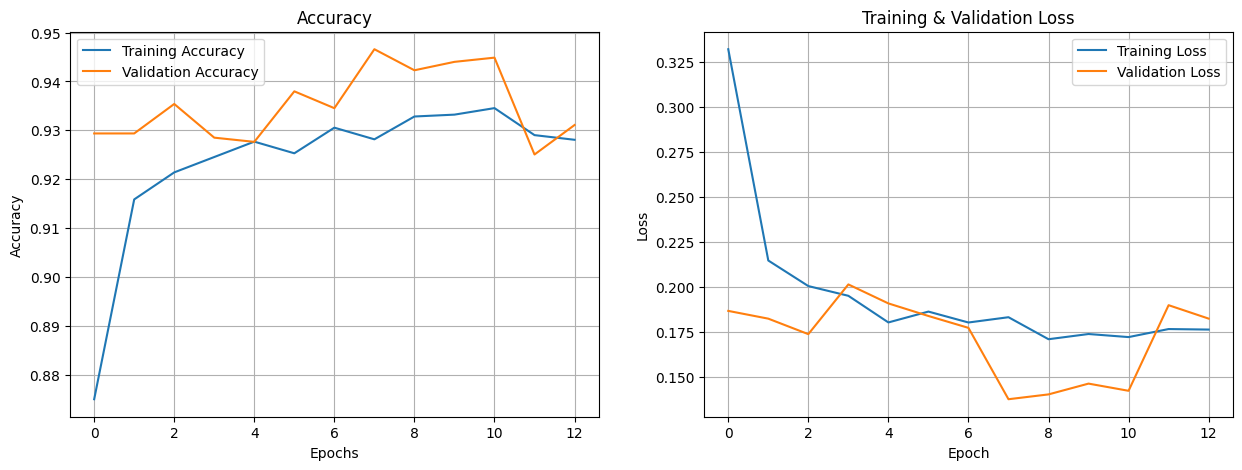

In [4]:
import matplotlib.pyplot as plt

fs = (15,5)

plt.figure(figsize = (fs))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

[[279  37]
 [ 25 820]] 



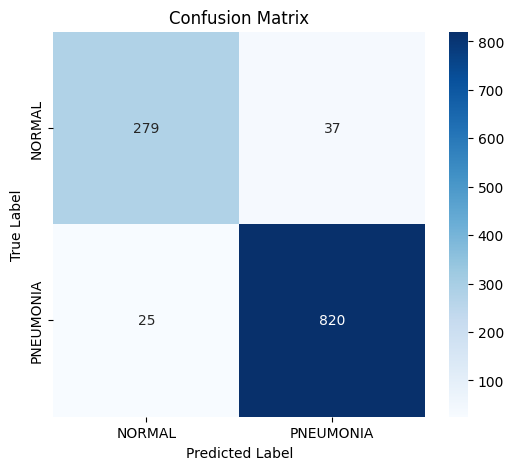

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_data.reset()

y_pred_prob = model.predict(val_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm,'\n')
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

Mounted at /content/drive
Saving Xception results to:
/content/drive/MyDrive/Pneumonia_Project/Xception
Model saved.
Training history saved.
Configuration saved.
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step
Classes: ['NORMAL', 'PNEUMONIA']
Class indices saved.


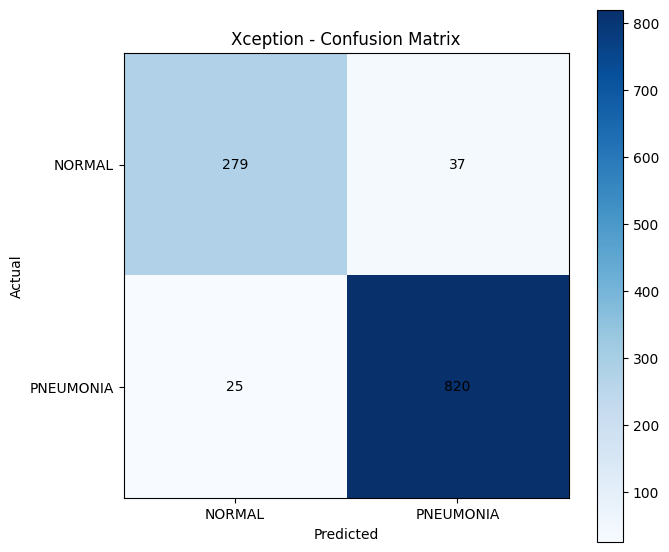

Confusion matrix saved.
              precision    recall  f1-score   support

      NORMAL     0.9178    0.8829    0.9000       316
   PNEUMONIA     0.9568    0.9704    0.9636       845

    accuracy                         0.9466      1161
   macro avg     0.9373    0.9267    0.9318      1161
weighted avg     0.9462    0.9466    0.9463      1161

Classification report saved.
Metrics CSV saved.


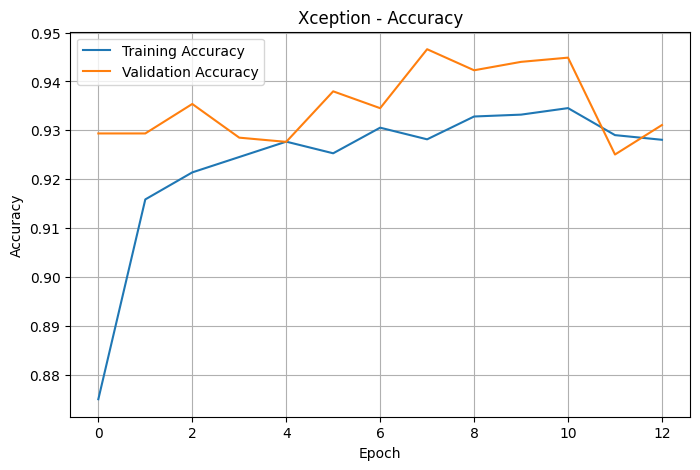

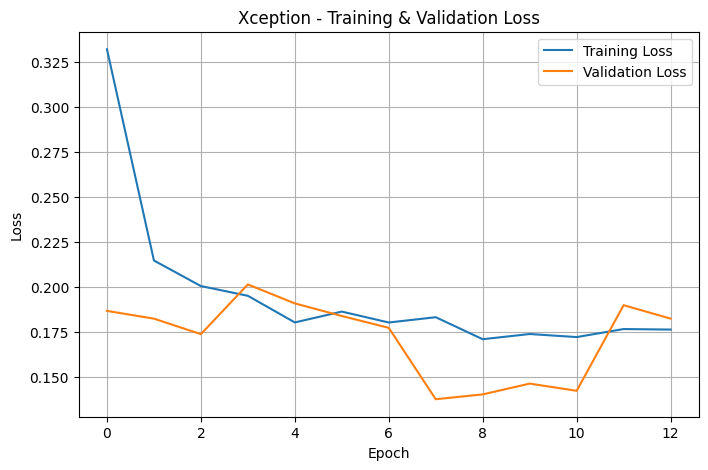

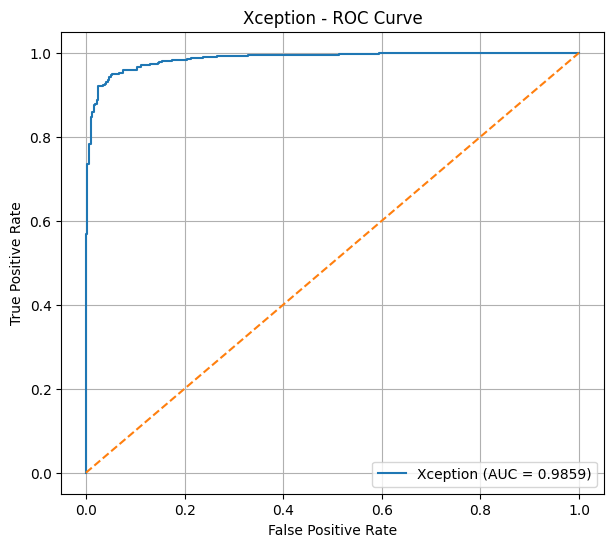

ROC-AUC: 0.9859
Validation Loss: 0.137716
Validation Accuracy: 0.946598
ROC-AUC: 0.985866

XCEPTION SAVING COMPLETE
All files saved in:
/content/drive/MyDrive/Pneumonia_Project/Xception


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

# ============================================================
# 1. CREATE XCEPTION FOLDER IN GOOGLE DRIVE
# ============================================================

save_dir = '/content/drive/MyDrive/Pneumonia_Project/Xception'
os.makedirs(save_dir, exist_ok=True)

print("Saving Xception results to:")
print(save_dir)


# ============================================================
# 2. SAVE TRAINED MODEL
# ============================================================

model.save(os.path.join(save_dir, 'xception.keras'))

print("Model saved.")


# ============================================================
# 3. SAVE TRAINING HISTORY
# ============================================================

with open(os.path.join(save_dir, 'history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

print("Training history saved.")


# ============================================================
# 4. SAVE MODEL CONFIGURATION
# ============================================================

config = {
    "model": "Xception",
    "weights": "imagenet",
    "input_shape": [299, 299, 3],
    "batch_size": bs,
    "epochs_requested": 30,
    "optimizer": "adam",
    "loss": "categorical_crossentropy",
    "augmentation": {
        "rotation_range": 20,
        "horizontal_flip": False,
        "zoom_range": 0.2,
        "width_shift_range": 0.1,
        "height_shift_range": 0.1
    },
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 5,
        "restore_best_weights": True
    }
}

with open(os.path.join(save_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=4)

print("Configuration saved.")


# ============================================================
# 5. GET VALIDATION PREDICTIONS
# ============================================================

val_data.reset()

pred_probs = model.predict(val_data)

pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_data.classes

class_names = list(val_data.class_indices.keys())

print("Classes:", class_names)


# ============================================================
# 6. SAVE CLASS INDICES
# ============================================================

with open(os.path.join(save_dir, 'class_indices.json'), 'w') as f:
    json.dump(val_data.class_indices, f, indent=4)

print("Class indices saved.")


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Xception - Confusion Matrix')
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=0
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, 'confusion_matrix.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Confusion matrix saved.")


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names,
    digits=4
)

print(report)

with open(
    os.path.join(save_dir, 'classification_report.txt'),
    'w'
) as f:
    f.write(report)

print("Classification report saved.")


# ============================================================
# 9. SAVE TRAINING METRICS AS CSV
# ============================================================

metrics_df = pd.DataFrame(history.history)

metrics_df.index = metrics_df.index + 1
metrics_df.index.name = 'epoch'

metrics_df.to_csv(
    os.path.join(save_dir, 'metrics.csv')
)

print("Metrics CSV saved.")


# ============================================================
# 10. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Xception - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(save_dir, 'accuracy_curve.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 11. LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Xception - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(save_dir, 'loss_curve.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 12. ROC CURVE
# ============================================================

# Probability of PNEUMONIA
pneumonia_index = val_data.class_indices['PNEUMONIA']

pneumonia_probs = pred_probs[:, pneumonia_index]

fpr, tpr, thresholds = roc_curve(
    true_classes,
    pneumonia_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Xception (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Xception - ROC Curve')
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(save_dir, 'roc_curve.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")


# ============================================================
# 13. SAVE FINAL EVALUATION
# ============================================================

loss, accuracy = model.evaluate(
    val_data,
    verbose=0
)

evaluation_text = (
    f"Validation Loss: {loss:.6f}\n"
    f"Validation Accuracy: {accuracy:.6f}\n"
    f"ROC-AUC: {roc_auc:.6f}\n"
)

with open(
    os.path.join(save_dir, 'evaluation.txt'),
    'w'
) as f:
    f.write(evaluation_text)

print(evaluation_text)


# ============================================================
# DONE
# ============================================================

print("========================================")
print("XCEPTION SAVING COMPLETE")
print("========================================")
print(f"All files saved in:\n{save_dir}")

In [6]:
import os
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
True
True
['Hackathon_topics.gdoc', 'Statistics Basics_Assignment.gdoc', 'Colab Notebooks', 'Regression Assignment.gdoc', 'NeuroChain: Automated Brand Misinformation Defense System.gdoc', "MANOJ SABALE's Resume (1).pdf", '1699687204754.gdoc', 'starred.png', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'Pneumonia_Project', 'programming_slm', 'MajorProject.ipynb']


In [16]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

# =========================
# VALIDATION DATA
# =========================

base_dir = '/content/pneumonia-1'
val_dir = os.path.join(base_dir, 'valid')

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(299, 299),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Validation generator recreated successfully")
print("Class indices:", val_data.class_indices)


Found 1161 images belonging to 2 classes.
Validation generator recreated successfully
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [17]:
from tensorflow.keras.models import load_model

model_path = '/content/drive/MyDrive/Pneumonia_Project/Xception/xception.keras'

model = load_model(model_path)

print("Xception model loaded successfully")

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import os
import numpy as np


# =========================
# XCEPTION FINAL METRICS
# =========================

# Reset validation generator
val_data.reset()

# Predictions
y_prob = model.predict(val_data, verbose=1)

# Predicted class
y_pred = np.argmax(y_prob, axis=1)

# True class
y_true = val_data.classes


# Validation loss + accuracy
val_loss, val_accuracy = model.evaluate(
    val_data,
    verbose=0
)


# Pneumonia class index
pneumonia_index = val_data.class_indices['PNEUMONIA']

# Probability of Pneumonia
y_score = y_prob[:, pneumonia_index]


# Classification metrics
precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

roc_auc = roc_auc_score(
    y_true,
    y_score
)


# =========================
# CREATE SAME FORMAT AS
# OTHER MODELS
# =========================

xception_metrics = pd.DataFrame([{
    'Accuracy': val_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC': roc_auc,
    'Validation Loss': val_loss
}])


# Save
save_path = '/content/drive/MyDrive/Pneumonia_Project/Xception/metrics.csv'

xception_metrics.to_csv(
    save_path,
    index=False
)


print(xception_metrics)
print("\nSaved to:")
print(save_path)

Xception model loaded successfully
19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step
   Accuracy  Precision    Recall  F1 Score   ROC AUC  Validation Loss
0  0.946598   0.956826  0.970414  0.963572  0.985866         0.137716

Saved to:
/content/drive/MyDrive/Pneumonia_Project/Xception/metrics.csv


In [18]:
import pandas as pd
import os

base_dir = '/content/drive/MyDrive/Pneumonia_Project'

model_paths = {
    'Baseline CNN': os.path.join(base_dir, 'Baseline_CNN', 'metrics.csv'),
    'VGG16': os.path.join(base_dir, 'VGG16', 'metrics.csv'),
    'InceptionV3': os.path.join(base_dir, 'InceptionV3', 'metrics.csv'),
    'ResNet50V2': os.path.join(base_dir, 'ResNet50V2', 'metrics.csv'),
    'Xception': os.path.join(base_dir, 'Xception', 'metrics.csv')
}

results = []

for model_name, path in model_paths.items():

    df = pd.read_csv(path)

    row = df.iloc[0].to_dict()
    row['Model'] = model_name

    results.append(row)


comparison = pd.DataFrame(results)

comparison = comparison[
    ['Model'] + [
        col for col in comparison.columns
        if col != 'Model'
    ]
]

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Validation Loss
0,Baseline CNN,0.941430,0.937993,0.984615,0.960739,0.979634,NaN
1,VGG16,0.950043,0.976970,0.953846,0.965269,0.990330,0.122976
2,InceptionV3,0.947459,0.975728,0.951479,0.963451,0.986068,0.147707
3,ResNet50V2,0.953488,0.969158,0.966864,0.968009,0.988892,0.119590
4,Xception,0.946598,0.956826,0.970414,0.963572,0.985866,0.137716


In [19]:
# =========================
# GRAD-CAM — RESNET50V2
# =========================

In [20]:
from tensorflow.keras.models import load_model

model_path = '/content/drive/MyDrive/Pneumonia_Project/ResNet50V2/resnet50v2.keras'

model = load_model(model_path)

print("ResNet50V2 loaded successfully")

model.summary()

ResNet50V2 loaded successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 26,719,240 (101.93 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 23,565,824 (89.90 MB)

 Optimizer params: 2,102,278 (8.02 MB)

In [34]:
# ============================================================
# STEP 1 — LOAD THE SAVED RESNET50V2
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet_v2 import preprocess_input


# ==========================================
# LOAD FINAL RESNET50V2 MODEL
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/Pneumonia_Project/ResNet50V2/resnet50v2.keras"

model = load_model(MODEL_PATH)

print("ResNet50V2 loaded successfully")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)


# ============================================================
# STEP 2 — SET THE GRAD-CAM LAYER
# ============================================================

LAST_CONV_LAYER = "post_relu"

print("Grad-CAM layer:", LAST_CONV_LAYER)


# ============================================================
# STEP 3 — CREATE THE GRAD-CAM FUNCTION
# ============================================================

def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):

    # Model that returns:
    # 1. feature maps
    # 2. final predictions

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        # If class isn't specified,
        # explain the model's predicted class

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradient of class prediction
    # with respect to feature maps

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients over spatial dimensions

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension

    conv_outputs = conv_outputs[0]

    # Weight feature maps

    heatmap = conv_outputs @ pooled_grads[0][..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Keep positive activations

    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize

    max_value = tf.reduce_max(heatmap)

    if max_value != 0:
        heatmap /= max_value

    return heatmap.numpy()


# ============================================================
# STEP 4 — BUILD THE ACTUAL PREDICTION + GRAD-CAM FUNCTION
# ============================================================

def predict_with_gradcam(image_path):

    # ==========================================
    # 1. LOAD IMAGE
    # ==========================================

    original = cv2.imread(image_path)

    if original is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Convert BGR → RGB

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # Resize for visualization

    original_display = cv2.resize(
        original,
        (224, 224)
    )


    # ==========================================
    # 2. PREPARE IMAGE FOR RESNET50V2
    # ==========================================

    img = cv2.resize(
        original,
        (224, 224)
    )

    img_array = img.astype(
        np.float32
    )

    # Add batch dimension
    # (224,224,3) → (1,224,224,3)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # ResNet50V2 preprocessing

    img_array = preprocess_input(
        img_array
    )


    # ==========================================
    # 3. MODEL PREDICTION
    # ==========================================

    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_class = np.argmax(
        predictions
    )

    confidence = predictions[
        predicted_class
    ]


    # ==========================================
    # 4. CLASS NAME
    # ==========================================

    class_names = {
        0: "NORMAL",
        1: "PNEUMONIA"
    }

    predicted_label = class_names[
        predicted_class
    ]


    # ==========================================
    # 5. GRAD-CAM
    # ==========================================

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        LAST_CONV_LAYER,
        pred_index=predicted_class
    )


    # ==========================================
    # 6. RESIZE HEATMAP
    # ==========================================

    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )


    # ==========================================
    # 7. COLOR HEATMAP
    # ==========================================

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # Convert BGR → RGB

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )


    # ==========================================
    # 8. CREATE OVERLAY
    # ==========================================

    overlay = cv2.addWeighted(
        original_display,
        0.6,
        heatmap_color,
        0.4,
        0
    )


    # ==========================================
    # 9. DISPLAY RESULTS
    # ==========================================

    plt.figure(
        figsize=(15, 5)
    )


    # Original X-ray

    plt.subplot(
        1, 3, 1
    )

    plt.imshow(
        original_display
    )

    plt.title(
        f"Original X-ray\n"
        f"Prediction: {predicted_label}"
    )

    plt.axis("off")


    # Grad-CAM Heatmap

    plt.subplot(
        1, 3, 2
    )

    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )

    plt.title(
        "Grad-CAM Heatmap"
    )

    plt.axis("off")


    # Overlay

    plt.subplot(
        1, 3, 3
    )

    plt.imshow(
        overlay
    )

    plt.title(
        f"Grad-CAM Overlay\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.axis("off")


    plt.tight_layout()
    plt.show()


    # ==========================================
    # 10. RETURN RESULTS
    # ==========================================

    return {
        "prediction": predicted_label,
        "confidence": float(confidence),
        "heatmap": heatmap,
        "overlay": overlay
    }


print("Grad-CAM pipeline ready!")

ResNet50V2 loaded successfully
Input shape : (None, 224, 224, 3)
Output shape: (None, 2)
Grad-CAM layer: post_relu
Grad-CAM pipeline ready!


NORMAL images   : 316
PNEUMONIA images: 845
TEST IMAGE 1
Actual class: NORMAL
Path: /content/pneumonia-1/valid/NORMAL/NORMAL2-IM-1422-0001_jpeg.rf.598178a995048336d8c02f5fbb7925e3.jpg


The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))


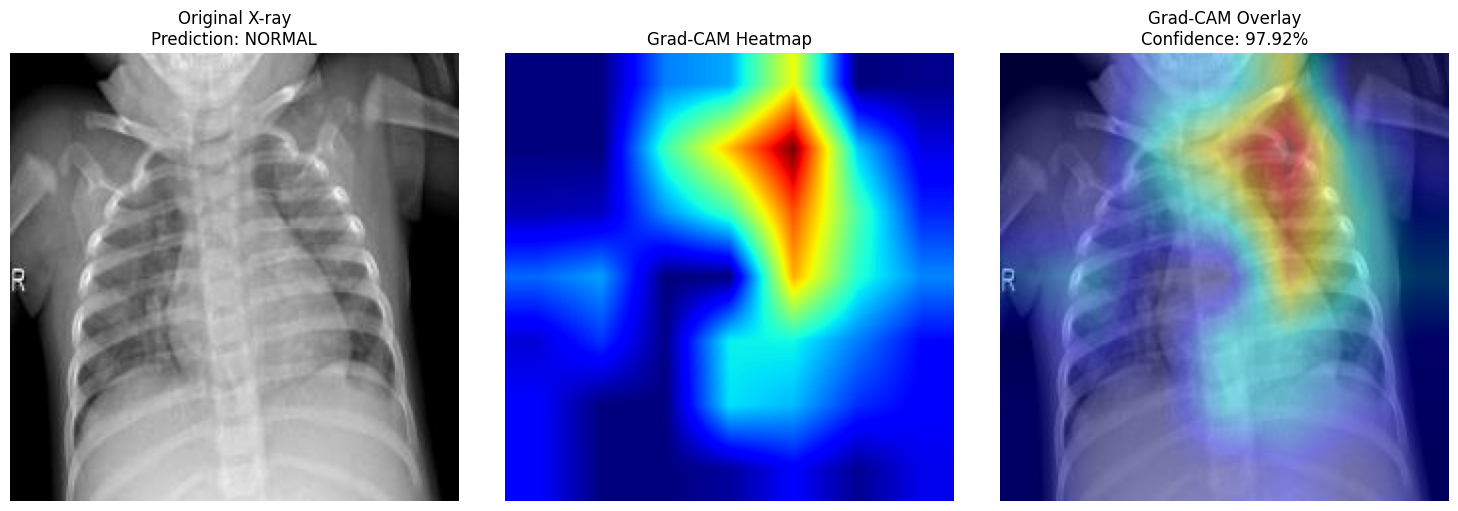

Predicted : NORMAL
Confidence: 97.92%
TEST IMAGE 2
Actual class: NORMAL
Path: /content/pneumonia-1/valid/NORMAL/NORMAL2-IM-1226-0001_jpeg.rf.abb195a01afc3f22936a99d5e634948b.jpg


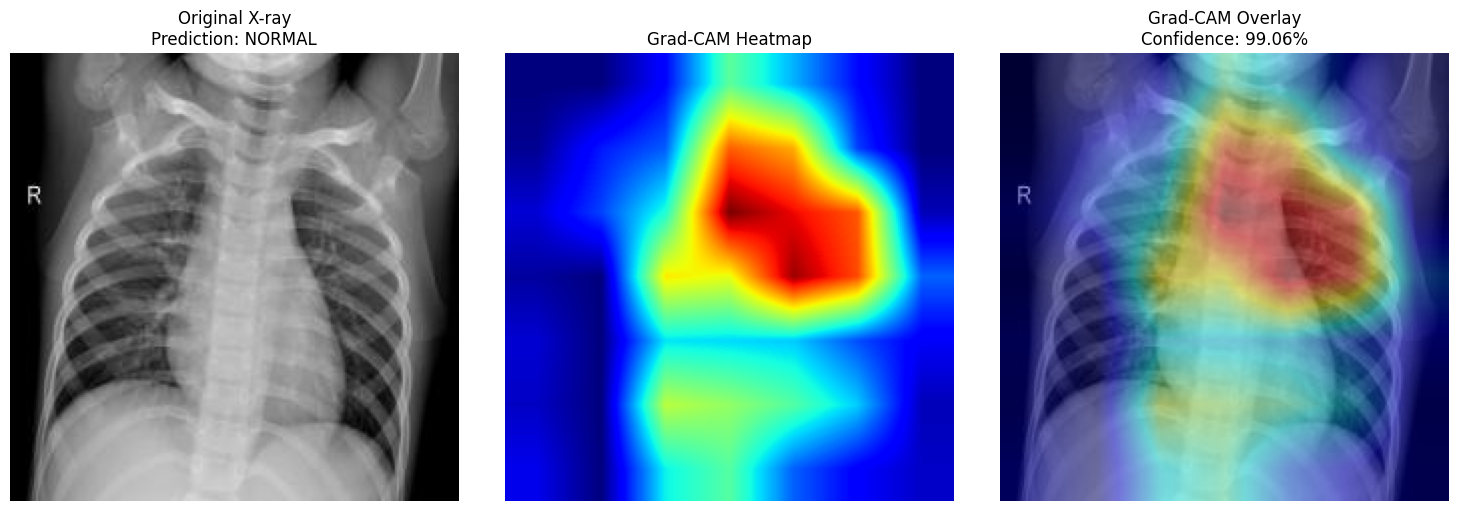

Predicted : NORMAL
Confidence: 99.06%
TEST IMAGE 3
Actual class: PNEUMONIA
Path: /content/pneumonia-1/valid/PNEUMONIA/person1486_bacteria_3885_jpeg.rf.f1c3779985f621366162395a40bdec2a.jpg


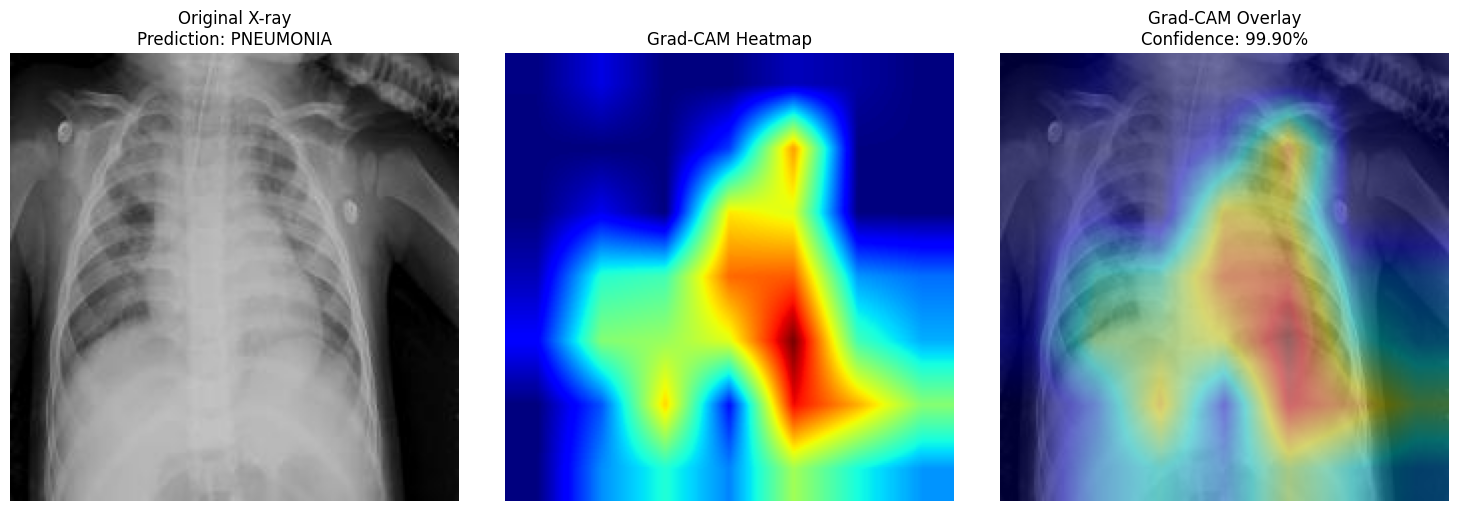

Predicted : PNEUMONIA
Confidence: 99.90%
TEST IMAGE 4
Actual class: PNEUMONIA
Path: /content/pneumonia-1/valid/PNEUMONIA/person1686_bacteria_4466_jpeg.rf.e0087338b76499a25c86404944694cac.jpg


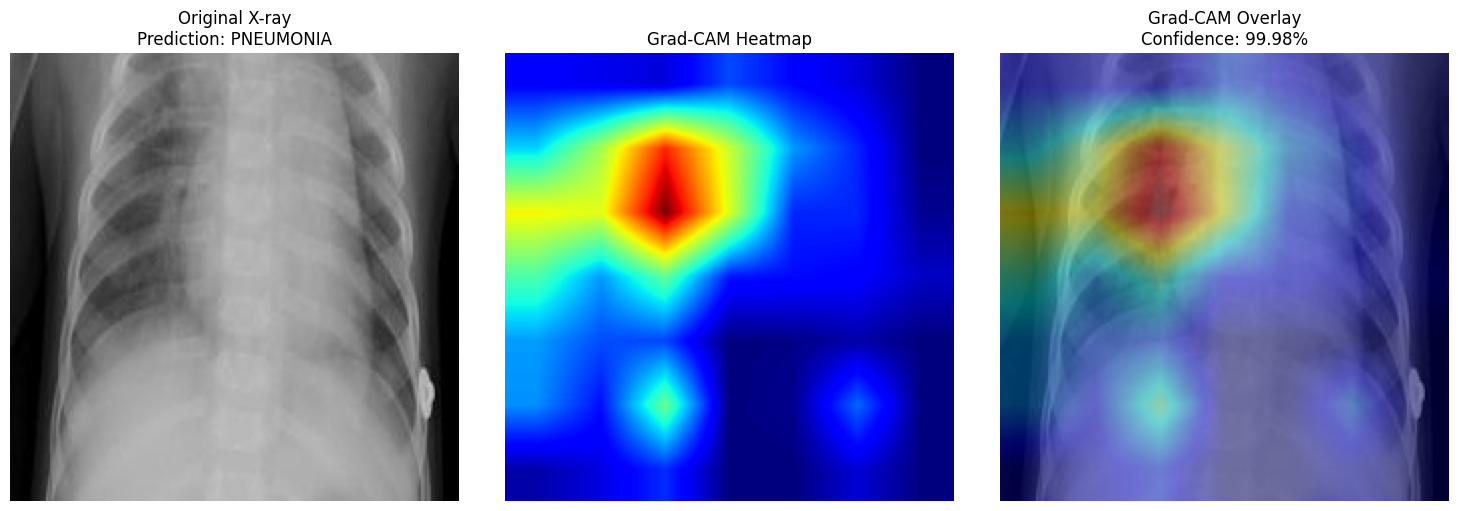

Predicted : PNEUMONIA
Confidence: 99.98%


In [35]:
# ============================================================
# STEP 5 — TEST GRAD-CAM ON MULTIPLE REAL X-RAYS
# ============================================================

import glob
import random

# Get validation images
normal_images = glob.glob(
    "/content/pneumonia-1/valid/NORMAL/*"
)

pneumonia_images = glob.glob(
    "/content/pneumonia-1/valid/PNEUMONIA/*"
)

print("NORMAL images   :", len(normal_images))
print("PNEUMONIA images:", len(pneumonia_images))


# Pick 2 images from each class
test_images = (
    random.sample(normal_images, 2)
    + random.sample(pneumonia_images, 2)
)


# Run Grad-CAM
for i, image_path in enumerate(test_images, 1):

    print("=" * 70)
    print(f"TEST IMAGE {i}")
    print("Actual class:",
          "NORMAL" if "/NORMAL/" in image_path else "PNEUMONIA")
    print("Path:", image_path)

    result = predict_with_gradcam(image_path)

    print("Predicted :", result["prediction"])
    print(
        "Confidence:",
        f"{result['confidence'] * 100:.2f}%"
    )


In [36]:
# ============================================================
# STEP 6 — FIND CORRECT AND INCORRECT PREDICTIONS
# ============================================================

import glob
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array


normal_images = glob.glob(
    "/content/pneumonia-1/valid/NORMAL/*"
)

pneumonia_images = glob.glob(
    "/content/pneumonia-1/valid/PNEUMONIA/*"
)


all_images = normal_images + pneumonia_images

results = []

class_names = {
    0: "NORMAL",
    1: "PNEUMONIA"
}


for image_path in all_images:

    # Load image
    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )

    # Prediction
    prediction = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_class = np.argmax(prediction)

    predicted_label = class_names[predicted_class]

    confidence = prediction[predicted_class]

    # Actual label
    if "/NORMAL/" in image_path:
        actual_label = "NORMAL"
    else:
        actual_label = "PNEUMONIA"

    # Correct / incorrect
    correct = (
        predicted_label == actual_label
    )

    results.append({
        "path": image_path,
        "actual": actual_label,
        "predicted": predicted_label,
        "confidence": float(confidence),
        "correct": correct
    })


print("Total images:", len(results))

print(
    "Correct predictions:",
    sum(r["correct"] for r in results)
)

print(
    "Incorrect predictions:",
    sum(not r["correct"] for r in results)
)

Total images: 1161
Correct predictions: 1107
Incorrect predictions: 54


In [37]:
# ============================================================
# STEP 7 — SELECT 2 CORRECT + 2 INCORRECT FROM EACH CLASS
# ============================================================

correct_normal = [
    r for r in results
    if r["actual"] == "NORMAL"
    and r["predicted"] == "NORMAL"
]

correct_pneumonia = [
    r for r in results
    if r["actual"] == "PNEUMONIA"
    and r["predicted"] == "PNEUMONIA"
]

wrong_normal = [
    r for r in results
    if r["actual"] == "NORMAL"
    and r["predicted"] == "PNEUMONIA"
]

wrong_pneumonia = [
    r for r in results
    if r["actual"] == "PNEUMONIA"
    and r["predicted"] == "NORMAL"
]


print("Correct NORMAL:", len(correct_normal))
print("Correct PNEUMONIA:", len(correct_pneumonia))
print("Wrong NORMAL → PNEUMONIA:", len(wrong_normal))
print("Wrong PNEUMONIA → NORMAL:", len(wrong_pneumonia))


# Select examples
selected = (
    correct_normal[:2]
    + correct_pneumonia[:2]
    + wrong_normal[:2]
    + wrong_pneumonia[:2]
)


print("\nSelected images:")

for i, r in enumerate(selected, 1):

    print(
        f"{i}. Actual={r['actual']} | "
        f"Predicted={r['predicted']} | "
        f"Confidence={r['confidence'] * 100:.2f}%"
    )

    print("   ", r["path"])

Correct NORMAL: 290
Correct PNEUMONIA: 817
Wrong NORMAL → PNEUMONIA: 26
Wrong PNEUMONIA → NORMAL: 28

Selected images:
1. Actual=NORMAL | Predicted=NORMAL | Confidence=89.17%
    /content/pneumonia-1/valid/NORMAL/IM-0553-0001_jpeg.rf.ddeaa7dfb4ff52aeca327a5628604c1a.jpg
2. Actual=NORMAL | Predicted=NORMAL | Confidence=97.81%
    /content/pneumonia-1/valid/NORMAL/IM-0439-0001_jpeg.rf.539f8f4dcb03166f073a747818fb138e.jpg
3. Actual=PNEUMONIA | Predicted=PNEUMONIA | Confidence=99.80%
    /content/pneumonia-1/valid/PNEUMONIA/person441_bacteria_1902_jpeg.rf.133880d812d4363d8081abfb23a7ba00.jpg
4. Actual=PNEUMONIA | Predicted=PNEUMONIA | Confidence=99.85%
    /content/pneumonia-1/valid/PNEUMONIA/person1320_bacteria_3348_jpeg.rf.7c5a647c7663eddbbfd4e4c474589265.jpg
5. Actual=NORMAL | Predicted=PNEUMONIA | Confidence=98.08%
    /content/pneumonia-1/valid/NORMAL/NORMAL2-IM-1401-0001_jpeg.rf.a7024dc0fc1e34e439631a55ad596ed2.jpg
6. Actual=NORMAL | Predicted=PNEUMONIA | Confidence=72.14%
    /conte

CASE 1
Actual     : NORMAL
Predicted  : NORMAL
Confidence : 89.17%


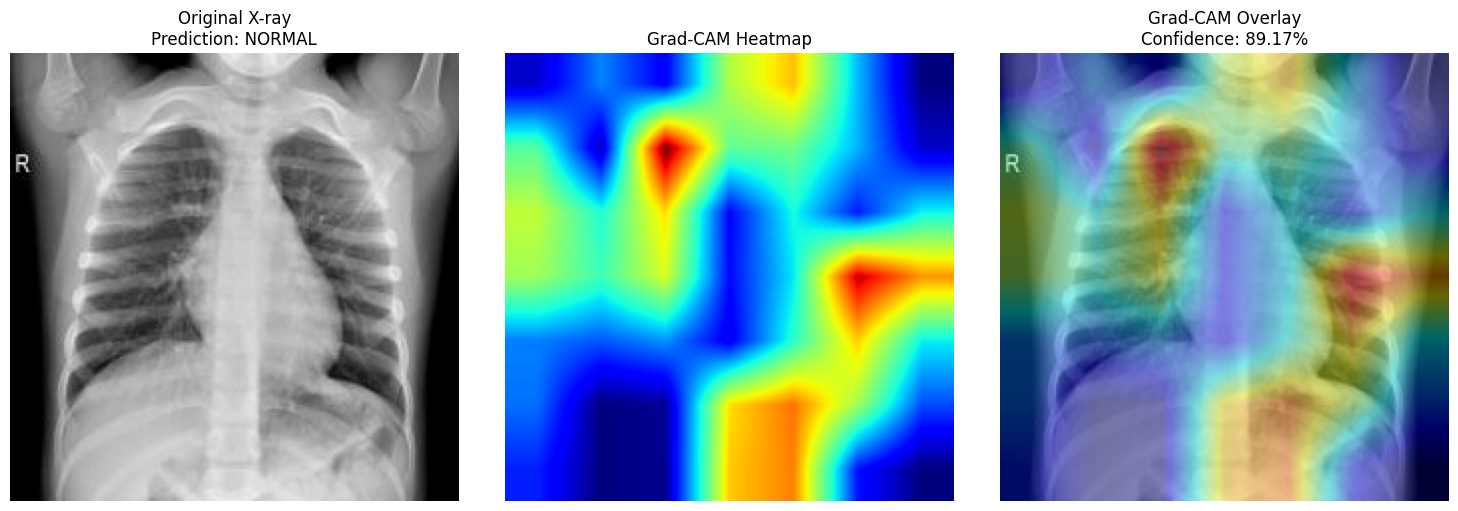

CASE 2
Actual     : NORMAL
Predicted  : NORMAL
Confidence : 97.81%


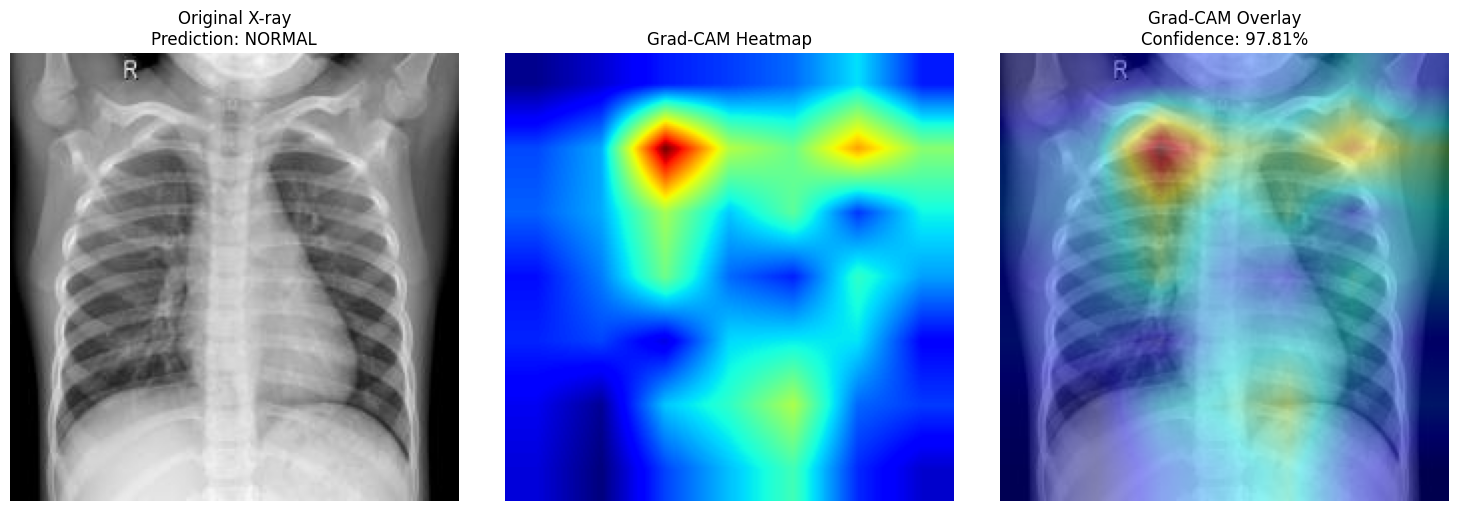

CASE 3
Actual     : PNEUMONIA
Predicted  : PNEUMONIA
Confidence : 99.80%


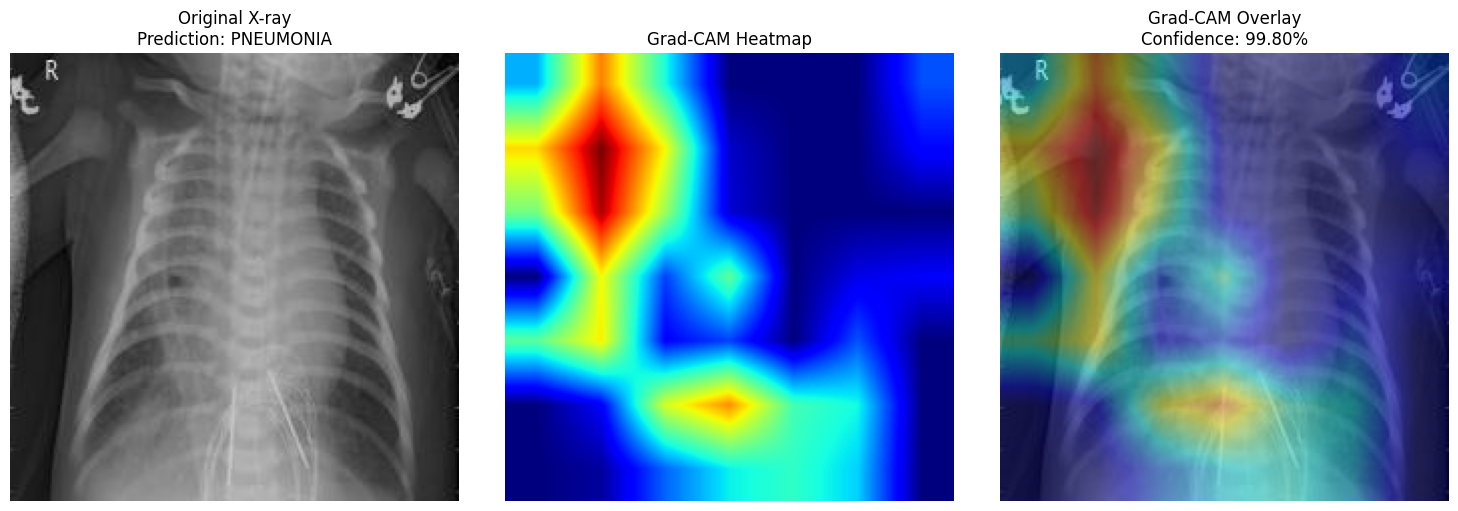

CASE 4
Actual     : PNEUMONIA
Predicted  : PNEUMONIA
Confidence : 99.85%


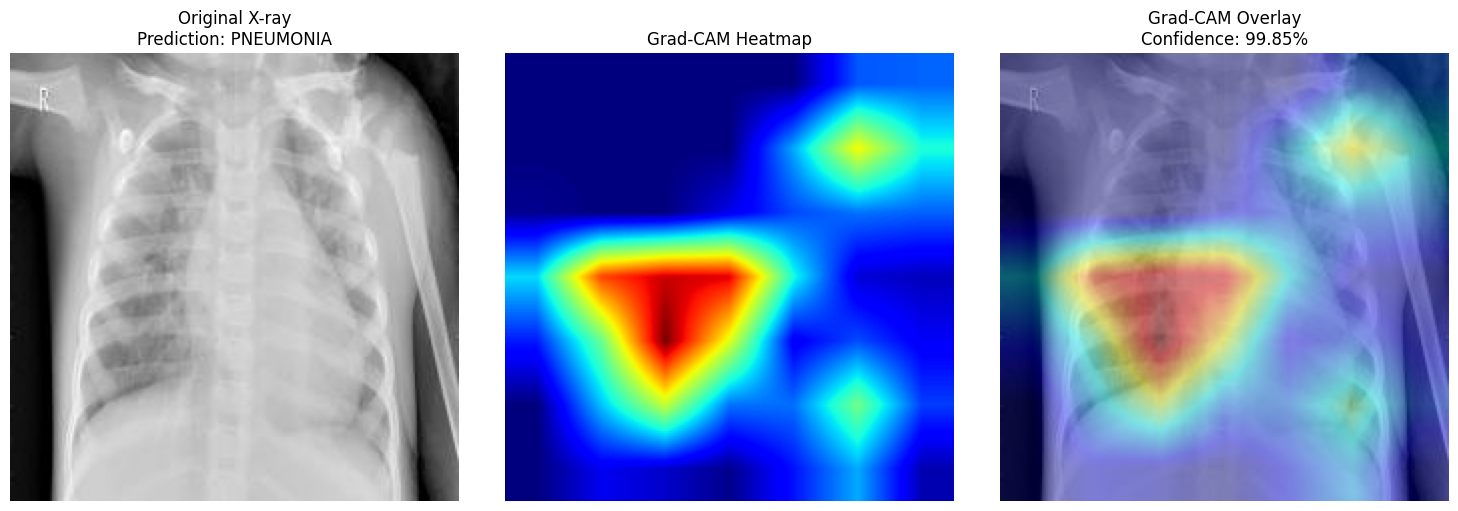

CASE 5
Actual     : NORMAL
Predicted  : PNEUMONIA
Confidence : 98.08%


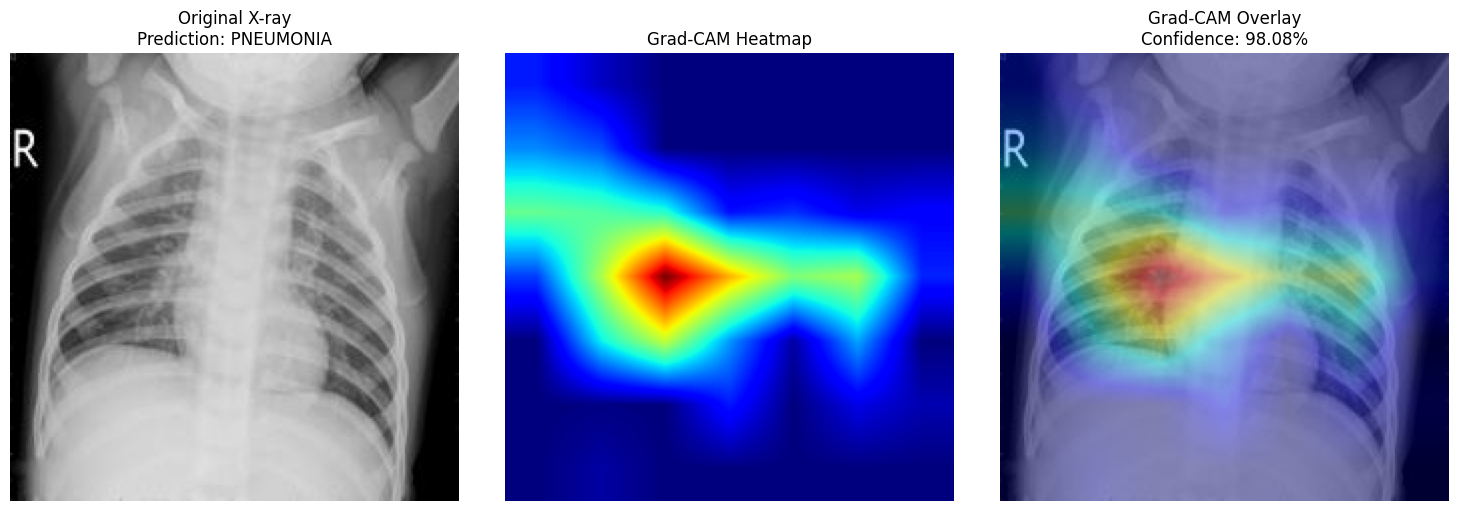

CASE 6
Actual     : NORMAL
Predicted  : PNEUMONIA
Confidence : 72.14%


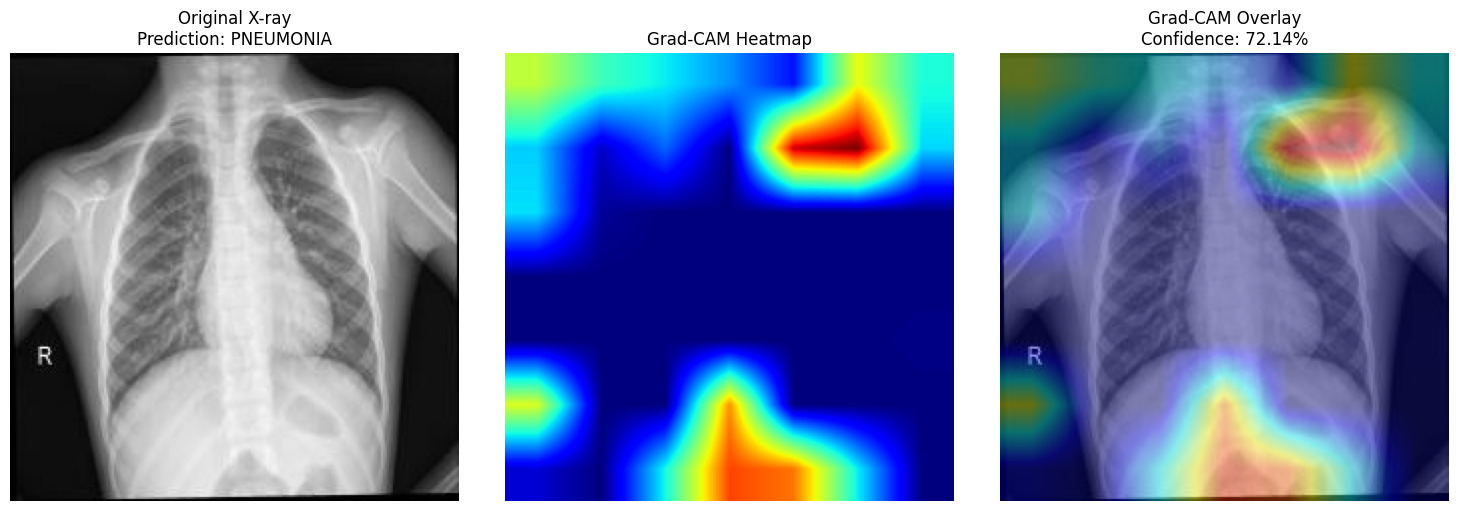

CASE 7
Actual     : PNEUMONIA
Predicted  : NORMAL
Confidence : 99.21%


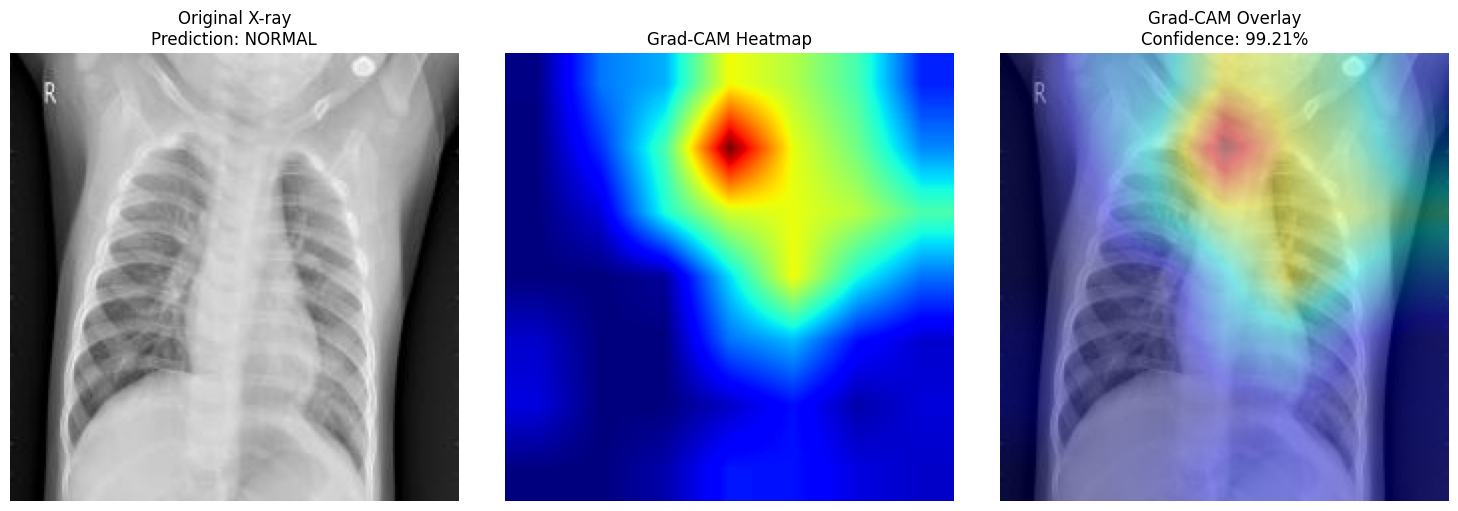

CASE 8
Actual     : PNEUMONIA
Predicted  : NORMAL
Confidence : 52.35%


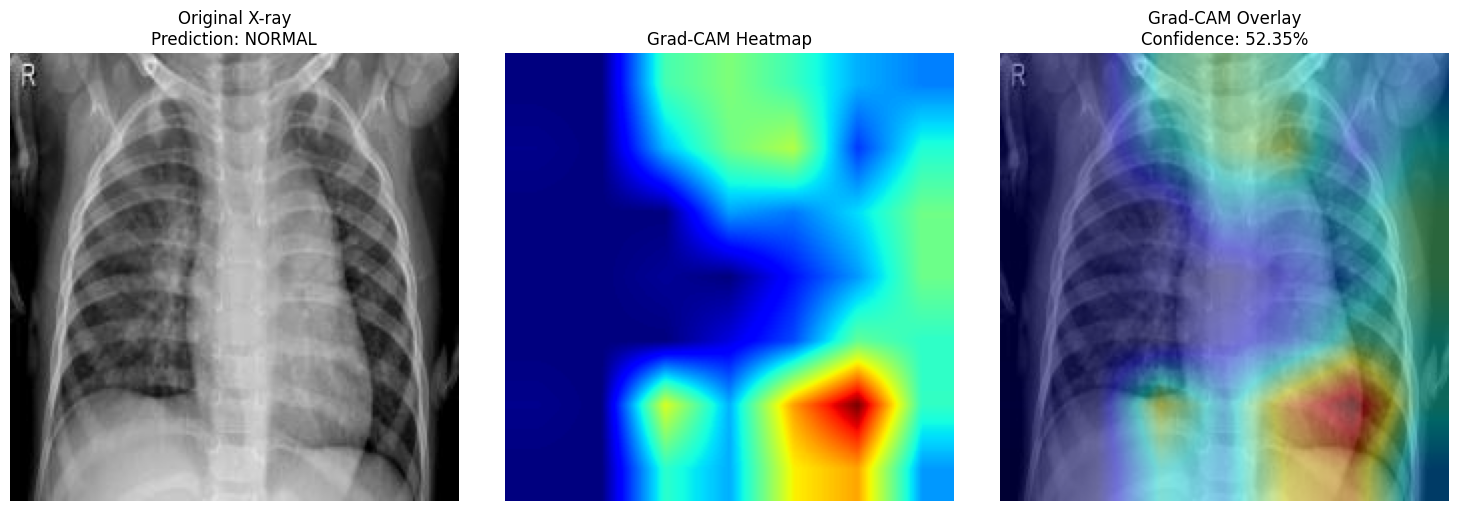

In [38]:
# ============================================================
# STEP 8 — GRAD-CAM ANALYSIS OF SELECTED CASES
# ============================================================

for i, r in enumerate(selected, 1):

    print("=" * 80)
    print(f"CASE {i}")
    print(f"Actual     : {r['actual']}")
    print(f"Predicted  : {r['predicted']}")
    print(f"Confidence : {r['confidence'] * 100:.2f}%")
    print("=" * 80)

    result = predict_with_gradcam(r["path"])

In [39]:
# ============================================================
# CREATE GRAD-CAM PROJECT FOLDER
# ============================================================

import os

GRADCAM_DIR = "/content/drive/MyDrive/Pneumonia_Project/GradCAM"

os.makedirs(GRADCAM_DIR, exist_ok=True)

print("Grad-CAM folder created:")
print(GRADCAM_DIR)

Grad-CAM folder created:
/content/drive/MyDrive/Pneumonia_Project/GradCAM


In [40]:
# ============================================================
# CREATE GRAD-CAM RESULT FOLDERS
# ============================================================

folders = [
    "correct_normal",
    "correct_pneumonia",
    "false_positive",
    "false_negative"
]

for folder in folders:
    os.makedirs(
        os.path.join(GRADCAM_DIR, folder),
        exist_ok=True
    )

print("Grad-CAM result folders created.")

Grad-CAM result folders created.


In [41]:
# ============================================================
# SAVE GRAD-CAM RESULT
# ============================================================

def save_gradcam_result(
    image_path,
    category,
    filename
):

    # ------------------------------------------
    # Read image
    # ------------------------------------------

    original = cv2.imread(image_path)

    if original is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    original_display = cv2.resize(
        original,
        (224, 224)
    )


    # ------------------------------------------
    # Prepare image
    # ------------------------------------------

    img_array = original_display.astype(
        np.float32
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )


    # ------------------------------------------
    # Prediction
    # ------------------------------------------

    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_class = np.argmax(
        predictions
    )

    confidence = predictions[
        predicted_class
    ]

    class_names = {
        0: "NORMAL",
        1: "PNEUMONIA"
    }

    predicted_label = class_names[
        predicted_class
    ]


    # ------------------------------------------
    # Grad-CAM
    # ------------------------------------------

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        LAST_CONV_LAYER,
        pred_index=predicted_class
    )


    # ------------------------------------------
    # Resize heatmap
    # ------------------------------------------

    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )


    # ------------------------------------------
    # Color heatmap
    # ------------------------------------------

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )


    # ------------------------------------------
    # Overlay
    # ------------------------------------------

    overlay = cv2.addWeighted(
        original_display,
        0.6,
        heatmap_color,
        0.4,
        0
    )


    # ------------------------------------------
    # Save figure
    # ------------------------------------------

    save_path = os.path.join(
        GRADCAM_DIR,
        category,
        filename
    )

    plt.figure(
        figsize=(15, 5)
    )

    plt.subplot(1, 3, 1)
    plt.imshow(original_display)
    plt.title(
        f"Original X-ray\n"
        f"Prediction: {predicted_label}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM Overlay\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    print("Saved:", save_path)

    return {
        "prediction": predicted_label,
        "confidence": float(confidence),
        "path": save_path
    }

In [42]:
# ============================================================
# SAVE ALL 8 SELECTED GRAD-CAM RESULTS
# ============================================================

categories = [
    "correct_normal",
    "correct_normal",
    "correct_pneumonia",
    "correct_pneumonia",
    "false_positive",
    "false_positive",
    "false_negative",
    "false_negative"
]

for i, (r, category) in enumerate(
    zip(selected, categories),
    start=1
):

    save_gradcam_result(
        image_path=r["path"],
        category=category,
        filename=f"case_{i}.png"
    )

print("\nAll Grad-CAM examples saved successfully.")

Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/correct_normal/case_1.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/correct_normal/case_2.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/correct_pneumonia/case_3.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/correct_pneumonia/case_4.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/false_positive/case_5.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/false_positive/case_6.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/false_negative/case_7.png
Saved: /content/drive/MyDrive/Pneumonia_Project/GradCAM/false_negative/case_8.png

All Grad-CAM examples saved successfully.


In [43]:
# ============================================================
# SAVE GRAD-CAM CODE TO DRIVE
# ============================================================

gradcam_code = r'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet_v2 import preprocess_input


# ============================================================
# MODEL
# ============================================================

MODEL_PATH = "resnet50v2.keras"

model = load_model(MODEL_PATH)

LAST_CONV_LAYER = "post_relu"


# ============================================================
# GRAD-CAM
# ============================================================

def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array
        )

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[0][
        ..., tf.newaxis
    ]

    heatmap = tf.squeeze(
        heatmap
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    if max_value != 0:
        heatmap /= max_value

    return heatmap.numpy()


# ============================================================
# PREDICTION + GRAD-CAM
# ============================================================

def predict_with_gradcam(image_path):

    original = cv2.imread(
        image_path
    )

    if original is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    original_display = cv2.resize(
        original,
        (224, 224)
    )

    img_array = original_display.astype(
        np.float32
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )

    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_class = np.argmax(
        predictions
    )

    confidence = predictions[
        predicted_class
    ]

    class_names = {
        0: "NORMAL",
        1: "PNEUMONIA"
    }

    predicted_label = class_names[
        predicted_class
    ]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        LAST_CONV_LAYER,
        pred_index=predicted_class
    )

    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_display,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    return {
        "prediction": predicted_label,
        "confidence": float(confidence),
        "heatmap": heatmap_resized,
        "overlay": overlay
    }
'''

GRADCAM_CODE_PATH = os.path.join(
    GRADCAM_DIR,
    "gradcam.py"
)

with open(
    GRADCAM_CODE_PATH,
    "w"
) as f:
    f.write(gradcam_code)

print("Grad-CAM code saved:")
print(GRADCAM_CODE_PATH)

Grad-CAM code saved:
/content/drive/MyDrive/Pneumonia_Project/GradCAM/gradcam.py
